# Calibration: fitting vulnerability to observed losses

This notebook walks through `natcat.calibration`: load an observed US-landfall loss
table, prepare one track and regional LitPop exposure per storm, run a small
hazard-parameter grid alongside the vulnerability fit, and apply the calibrated
model to Hurricane Michael (2018) — finishing with a comparison against the
parameters shipped as `ValueDependentVulnerability.calibrated()`. See
[Calibration](../docs/user-guide/calibration.md) and
[Calibration methodology](../docs/methodology/calibration.md) for the full write-up,
in particular the caveats around the bundled loss data before reading much into the
numbers below.

In [1]:
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from natcat import plotting

plotting.apply_style()
pd.options.display.float_format = "{:,.2f}".format


NumExpr defaulting to 10 threads.


## Observed losses

`load_observed_losses` reads the bundled NHC US-landfall table (total damage estimate
per storm from the NHC Tropical Cyclone Report, nominal USD of the loss year).
`normalise_losses` brings every storm to the price level of the exposure's reference
year (2018, LitPop's default) via GDP normalisation by default (`method="gdp"`, a
Pielke-style price &times; wealth &times; population proxy; `method="cpi"`,
prices only, is also available), and adds `observed_loss_ref_usd` &#8212; the
calibration target.

In [2]:
from natcat.calibration import load_observed_losses, normalise_losses

observed = normalise_losses(load_observed_losses(), reference_year=2018)  # GDP-normalised by default
print(f"{len(observed)} storms in the calibration set (surge/flood-dominated storms excluded)")
observed[["storm_id", "name", "year", "damage_driver", "observed_loss_usd", "observed_loss_ref_usd"]]

19 storms in the calibration set (surge/flood-dominated storms excluded)


,storm_id,name,year,damage_driver,observed_loss_usd,observed_loss_ref_usd
0,AL111989,Hugo,1989,mixed,"7,000,000,000.00","25,641,843,971.63"
1,AL041992,Andrew,1992,wind,"26,500,000,000.00","83,970,858,895.71"
2,AL171995,Opal,1995,mixed,"3,000,000,000.00","8,112,565,445.03"
3,AL061996,Fran,1996,mixed,"3,200,000,000.00","8,192,317,224.29"
4,AL032004,Charley,2004,wind,"15,000,000,000.00","25,380,835,380.84"
5,AL062004,Frances,2004,mixed,"9,000,000,000.00","15,228,501,228.50"
6,AL092004,Ivan,2004,mixed,"14,200,000,000.00","24,027,190,827.19"
7,AL112004,Jeanne,2004,wind,"6,900,000,000.00","11,675,184,275.18"
8,AL042005,Dennis,2005,mixed,"2,230,000,000.00","3,533,113,496.93"
9,AL252005,Wilma,2005,wind,"20,600,000,000.00","32,637,730,061.35"


## Inputs and cases

A storm's track and regional exposure don't depend on the hazard or vulnerability
parameters, so `prepare_inputs` downloads each best track, derives an exposure box
around its landfall, and loads the regional LitPop exposure once per storm &#8212;
the slow part, and cached so a repeated run (including the hazard grid below, which
needs the footprint re-evaluated at several hazard settings) skips it entirely.
`cases_from_inputs` then evaluates the wind footprint at a chosen hazard to produce
the `StormCase`s the calibrator actually fits against. We reuse a cached set of
inputs if one exists from a previous run of this notebook or `scripts/calibrate.py`.

In [3]:
from pathlib import Path

from natcat.calibration import cases_from_inputs, load_inputs, prepare_inputs, save_inputs

inputs_path = Path("..") / ".cache" / "calibration_inputs.pkl"
if inputs_path.exists():
    inputs = load_inputs(inputs_path)
    print(f"Loaded {len(inputs)} cached inputs from {inputs_path}")
else:
    inputs = prepare_inputs(observed)
    save_inputs(inputs, inputs_path)
    print(f"Prepared and cached {len(inputs)} inputs to {inputs_path}")

cases = cases_from_inputs(inputs)   # wind footprint at the default hazard

Loaded 19 cached inputs from ../.cache/calibration_inputs.pkl


## Baseline: before calibration

`ValueDependentVulnerability()` with its defaults (`v50_slope=0`) is exactly a single
`WindVulnerability` curve. How far off is it from the observed losses before any
fitting?

In [4]:
from natcat.calibration import Calibrator
from natcat.vulnerability import ValueDependentVulnerability

calibrator = Calibrator(cases, ValueDependentVulnerability())

baseline = pd.DataFrame(
    {
        "storm": [c.name for c in cases],
        "observed": calibrator.observed,
        "modelled (uncalibrated)": calibrator.modelled_losses(),
    }
)
baseline["ratio"] = baseline["modelled (uncalibrated)"] / baseline["observed"]
baseline

,storm,observed,modelled (uncalibrated),ratio
0,Hugo,"25,641,843,971.63","120,874,192,051.94",4.71
1,Andrew,"83,970,858,895.71","733,983,237,304.09",8.74
2,Opal,"8,112,565,445.03","26,179,642,102.36",3.23
3,Fran,"8,192,317,224.29","26,066,933,491.43",3.18
4,Charley,"25,380,835,380.84","250,159,175,932.10",9.86
5,Frances,"15,228,501,228.50","29,567,623,729.12",1.94
6,Ivan,"24,027,190,827.19","24,749,945,657.77",1.03
7,Jeanne,"11,675,184,275.18","83,676,670,291.06",7.17
8,Dennis,"3,533,113,496.93","36,228,537,234.88",10.25
9,Wilma,"32,637,730,061.35","539,017,685,032.83",16.52


## Fit at the default hazard

`method="global"` runs differential evolution over the model's default parameter
bounds, followed by a local Nelder-Mead polish. 100 iterations is enough for a
reasonable fit and keeps this notebook's runtime short; `scripts/calibrate.py` uses
200 by default for the documentation figures. This fit uses the default hazard
(`TropicalCycloneHazard`'s `decay_exponent`/`asymmetry_factor` defaults); the next
section lets the hazard shape vary too.

In [5]:
result = calibrator.fit(method="global", maxiter=100, seed=0)
print(result.summary())

Calibration (global, 7737 evaluations): Maximum number of iterations has been exceeded.; polished
    threshold_kt:        40 ->        34
         v50_ref:       105 ->        80
       v50_slope:         0 ->     19.68
               k:      0.12 ->      0.08
           scale:         1 ->    0.5303
  objective     : 0.4080 -> 0.0761 (typical factor error 4.35x -> 1.89x)


In [6]:
result.table

,storm_id,name,observed,modelled_initial,modelled,log_ratio_initial,log_ratio,weight
0,AL111989,Hugo,"25,641,843,971.63","120,874,192,051.94","28,440,749,596.53",0.67,0.04,1.00
1,AL041992,Andrew,"83,970,858,895.71","733,983,237,304.09","138,705,047,693.43",0.94,0.22,1.00
2,AL171995,Opal,"8,112,565,445.03","26,179,642,102.36","7,311,596,942.51",0.51,-0.05,1.00
3,AL061996,Fran,"8,192,317,224.29","26,066,933,491.43","10,109,422,536.79",0.50,0.09,1.00
4,AL032004,Charley,"25,380,835,380.84","250,159,175,932.10","66,678,740,485.61",0.99,0.42,1.00
5,AL062004,Frances,"15,228,501,228.50","29,567,623,729.12","7,466,037,171.22",0.29,-0.31,1.00
6,AL092004,Ivan,"24,027,190,827.19","24,749,945,657.77","8,681,670,832.86",0.01,-0.44,1.00
7,AL112004,Jeanne,"11,675,184,275.18","83,676,670,291.06","17,607,283,148.51",0.86,0.18,1.00
8,AL042005,Dennis,"3,533,113,496.93","36,228,537,234.88","9,811,347,828.91",1.01,0.44,1.00
9,AL252005,Wilma,"32,637,730,061.35","539,017,685,032.83","47,933,332,836.33",1.22,0.17,1.00


## Hazard-parameter grid

The Rankine decay exponent and motion-asymmetry factor change the wind footprint
itself, so `calibrate_hazard_grid` treats them as an outer loop: it rebuilds the
hazard, recomputes every storm's footprint from `inputs`, refits the vulnerability,
and keeps the grid point with the lowest calibrated objective. This uses a reduced
grid and a short `maxiter` to keep the notebook's runtime down;
`scripts/calibrate.py` uses the full grid
(`decay_exponents=(0.5, 0.75, 1.0, 1.5, 2.0)`, `asymmetry_factors=(0.3, 0.5, 0.7)`,
`maxiter=200`) for the documentation figures and finds `decay_exponent=0.5,
asymmetry_factor=0.3` &#8212; now the package defaults.

In [7]:
from natcat.calibration import calibrate_hazard_grid

grid = calibrate_hazard_grid(
    inputs,
    ValueDependentVulnerability(),
    decay_exponents=(0.5, 1.0, 2.0),
    asymmetry_factors=(0.3, 0.5),
    maxiter=60,
    seed=0,
)
print(grid.summary())
result = grid.best   # supersede the single-hazard fit above with the grid winner

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hazard grid:   0%|          | 0/6 [00:00<?, ?it/s]

exponent=0.5 asymmetry=0.3 -> factor error 1.89x


Hazard grid:  17%|█▋        | 1/6 [00:29<02:27, 29.45s/it]

exponent=0.5 asymmetry=0.5 -> factor error 1.96x


...

Hazard grid:  83%|████████▎ | 5/6 [02:28<00:29, 29.55s/it]

exponent=2 asymmetry=0.5 -> factor error 2.37x


Hazard grid: 100%|██████████| 6/6 [02:56<00:00, 29.32s/it]

Hazard grid: 100%|██████████| 6/6 [02:56<00:00, 29.48s/it]

Hazard grid (calibrated factor error per point):
decay_exponent    0.50  1.00  2.00
asymmetry_factor                  
0.30              1.89  2.03  2.30
0.50              1.96  2.09  2.37
Best: decay_exponent=0.5, asymmetry_factor=0.3
Calibration (global, 4679 evaluations): Maximum number of iterations has been exceeded.; polished
    threshold_kt:        40 ->        34
         v50_ref:       105 ->     80.04
       v50_slope:         0 ->     19.51
               k:      0.12 ->      0.08
           scale:         1 ->    0.5199
  objective     : 0.4080 -> 0.0761 (typical factor error 4.35x -> 1.89x)


## Plots

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)


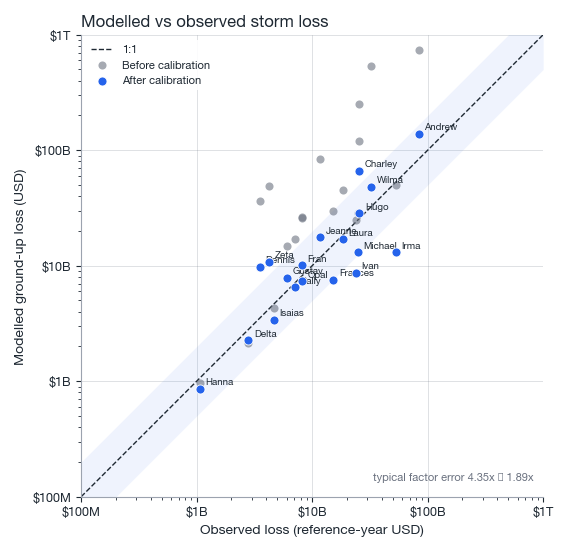

In [8]:
fig, ax = plotting.plot_calibration(result, title="Modelled vs observed storm loss")

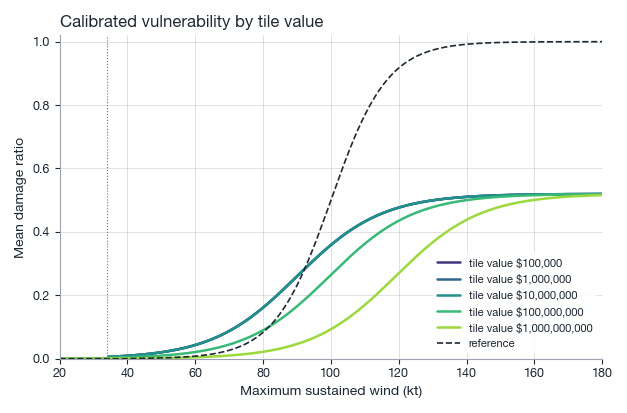

In [9]:
from natcat.vulnerability import WindVulnerability

fig, ax = plotting.plot_value_dependent_curves(
    result.model,
    reference=WindVulnerability("Frame"),
    title="Calibrated vulnerability by tile value",
)

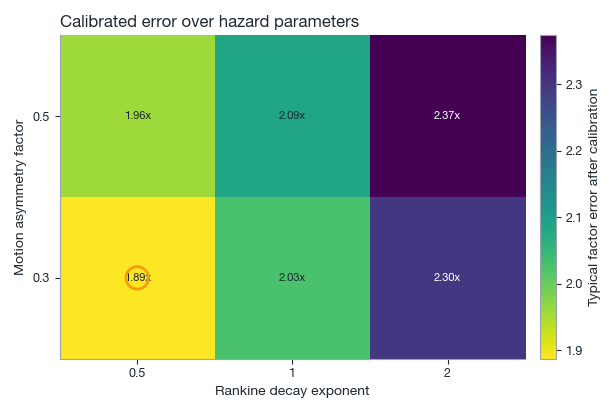

In [10]:
fig, ax = plotting.plot_hazard_grid(grid, title="Calibrated error over hazard parameters")

## Applying the calibrated model to Hurricane Michael

`result.model` is a plain `VulnerabilityModel`, so it drops straight into
`LossCalculator` in place of `WindVulnerability`. We build the hazard at the grid's
winning parameters (`grid.hazard_factory()`) and compare both vulnerability models on
the same Hurricane Michael (2018) footprint and LitPop portfolio used in the
single-event notebook.

In [11]:
from natcat.exposure import load_litpop_exposure
from natcat.hazards import TropicalCycloneHazard
from natcat.loss import LossCalculator
from natcat.tracks import load_best_track

track = load_best_track(2018, "al", "14")
portfolio = load_litpop_exposure("USA", bounds=(24.5, 32.0, -87.6, -80.0))
hazard = grid.hazard_factory()(track)   # TropicalCycloneHazard at grid.best_hazard

loss_uncalibrated = LossCalculator(hazard, WindVulnerability()).compute(portfolio)["loss"].sum()
loss_calibrated = LossCalculator(hazard, result.model).compute(portfolio)["loss"].sum()

print(f"WindVulnerability():  ${loss_uncalibrated:,.0f}")
print(f"result.model:         ${loss_calibrated:,.0f}")
print(f"NHC TCR estimate (reference-year USD): ${observed.loc[observed['name'] == 'Michael', 'observed_loss_ref_usd'].iloc[0]:,.0f}")

Fetching LitPop exposure for USA via the CLIMADA data API.


WindVulnerability():  $19,888,625,495
result.model:         $13,790,441,319
NHC TCR estimate (reference-year USD): $25,000,000,000


## Comparing with the shipped calibration

`ValueDependentVulnerability.calibrated()` ships the parameters from a full run of
`scripts/calibrate.py` against this same 19-storm set (the full hazard grid, 200
optimiser iterations): `decay_exponent=0.5, asymmetry_factor=0.3`, typical factor
error 1.77x. This notebook's reduced grid and shorter fit (`maxiter=60`) should land
in the same neighbourhood without necessarily reproducing it exactly.

In [12]:
from natcat.hazards.wind_field import DEFAULT_ASYMMETRY_FACTOR, DEFAULT_DECAY_EXPONENT
from natcat.vulnerability import ValueDependentVulnerability

calibrated = ValueDependentVulnerability.calibrated()
comparison = pd.DataFrame(
    {
        "this notebook": result.params,
        "shipped ValueDependentVulnerability.calibrated()": calibrated.params,
    }
)
print(f"This notebook's best hazard grid point: {grid.best_hazard}")
print(f"Shipped hazard defaults: decay_exponent={DEFAULT_DECAY_EXPONENT}, "
      f"asymmetry_factor={DEFAULT_ASYMMETRY_FACTOR}")
comparison

This notebook's best hazard grid point: {'decay_exponent': 0.5, 'asymmetry_factor': 0.3}
Shipped hazard defaults: decay_exponent=0.5, asymmetry_factor=0.3


,this notebook,shipped ValueDependentVulnerability.calibrated()
threshold_kt,34.00,34.00
v50_ref,80.04,80.00
v50_slope,19.51,19.70
k,0.08,0.08
scale,0.52,0.53


## Caveats

This calibration is fit to about 19 storms' total NHC-reported damage,
GDP-normalised (a national, not necessarily coastal-specific, growth proxy) but not
an insured, wind-only loss dataset, against a wind-only model and LitPop's proxy
asset values. See
[Calibration methodology &#8212; Caveats](../docs/methodology/calibration.md#caveats)
before using `result.model` (or `ValueDependentVulnerability.calibrated()`, or the
bundled loss table) for anything beyond exploring how the pipeline responds to a
different vulnerability curve or hazard parameterisation.